<a href="https://colab.research.google.com/github/EngMohamed-op/MBTI-Personality/blob/main/EDA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english') )
from wordcloud import WordCloud
import kagglehub
import matplotlib.ticker as mtick

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [97]:


# Download latest version
path = kagglehub.dataset_download("datasnaek/mbti-type")

print("Path to dataset files:", path)
df=pd.read_csv(path+"/mbti_1.csv")

Using Colab cache for faster access to the 'mbti-type' dataset.
Path to dataset files: /kaggle/input/mbti-type


In [98]:
df

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...
...,...,...
8670,ISFP,'https://www.youtube.com/watch?v=t8edHB_h908||...
8671,ENFP,'So...if this thread already exists someplace ...
8672,INTP,'So many questions when i do these things. I ...
8673,INFP,'I am very conflicted right now when it comes ...


In [99]:
df.isnull().sum()

,0
type,0
posts,0


In [100]:
df.duplicated().sum()

np.int64(0)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8675 entries, 0 to 8674
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    8675 non-null   object
 1   posts   8675 non-null   object
dtypes: object(2)
memory usage: 135.7+ KB


In [102]:
df.describe(include='object')

,type,posts
count,8675,8675
unique,16,8675
top,INFP,'It has been too long since I have been on per...
freq,1832,1


In [103]:
df['Word_count'] = df['posts'].apply(lambda x: len(x.replace('|||', ' ').split()))

In [104]:
df['avg_word_lenght']=df['posts'].apply(lambda x:np.mean([len(word) for word in x.split()]))

In [105]:
df

,type,posts,Word_count,avg_word_lenght
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,605,7.329137
1,ENTP,'I'm finding the lack of me in these posts ver...,1219,5.008547
2,INTP,'Good one _____ https://www.youtube.com/wat...,885,5.259569
3,INTJ,"'Dear INTP, I enjoyed our conversation the o...",1113,4.859962
4,ENTJ,'You're fired.|||That's another silly misconce...,1016,5.299897
...,...,...,...,...
8670,ISFP,'https://www.youtube.com/watch?v=t8edHB_h908||...,845,5.271357
8671,ENFP,'So...if this thread already exists someplace ...,1358,4.972498
8672,INTP,'So many questions when i do these things. I ...,997,5.032700
8673,INFP,'I am very conflicted right now when it comes ...,1754,4.515543


In [106]:

df['lexical_diversity'] = df['posts'].apply(lambda x: len(set(x.split())) / len(x.split()))


In [107]:

self_words = ['I', 'me', 'my', 'myself']
df['self_reference_ratio'] = df['posts'].apply(lambda x: sum(word in self_words for word in x.split()) / len(x.split()))

In [108]:

emotion_words = ['love', 'happy', 'sad', 'hate', 'excited', 'amazing', 'fun']
df['emotion_score'] = df['posts'].apply(lambda x: sum(word in emotion_words for word in x.split()) + x.count('!'))

In [109]:
df['IE'] = df['type'].apply(lambda x: x[0])
df['NS'] = df['type'].apply(lambda x: x[1])
df['TF'] = df['type'].apply(lambda x: x[2])
df['JP'] = df['type'].apply(lambda x: x[3])

df

,type,posts,Word_count,avg_word_lenght,lexical_diversity,self_reference_ratio,emotion_score,IE,NS,TF,JP
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,605,7.329137,0.674460,0.026978,3,I,N,F,J
1,ENTP,'I'm finding the lack of me in these posts ver...,1219,5.008547,0.508547,0.072650,2,E,N,T,P
2,INTP,'Good one _____ https://www.youtube.com/wat...,885,5.259569,0.608852,0.033493,6,I,N,T,P
3,INTJ,"'Dear INTP, I enjoyed our conversation the o...",1113,4.859962,0.531955,0.049812,5,I,N,T,J
4,ENTJ,'You're fired.|||That's another silly misconce...,1016,5.299897,0.549121,0.032058,2,E,N,T,J
...,...,...,...,...,...,...,...,...,...,...,...
8670,ISFP,'https://www.youtube.com/watch?v=t8edHB_h908||...,845,5.271357,0.559045,0.041457,9,I,S,F,P
8671,ENFP,'So...if this thread already exists someplace ...,1358,4.972498,0.499618,0.062643,43,E,N,F,P
8672,INTP,'So many questions when i do these things. I ...,997,5.032700,0.588608,0.030591,5,I,N,T,P
8673,INFP,'I am very conflicted right now when it comes ...,1754,4.515543,0.441056,0.070968,6,I,N,F,P


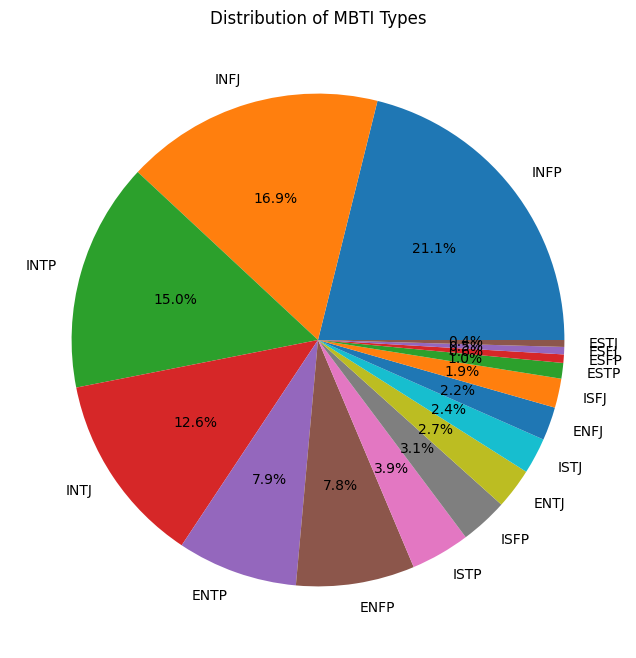

In [110]:
plt.figure(figsize=(8,8))
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribution of MBTI Types")
plt.ylabel("")
plt.show()


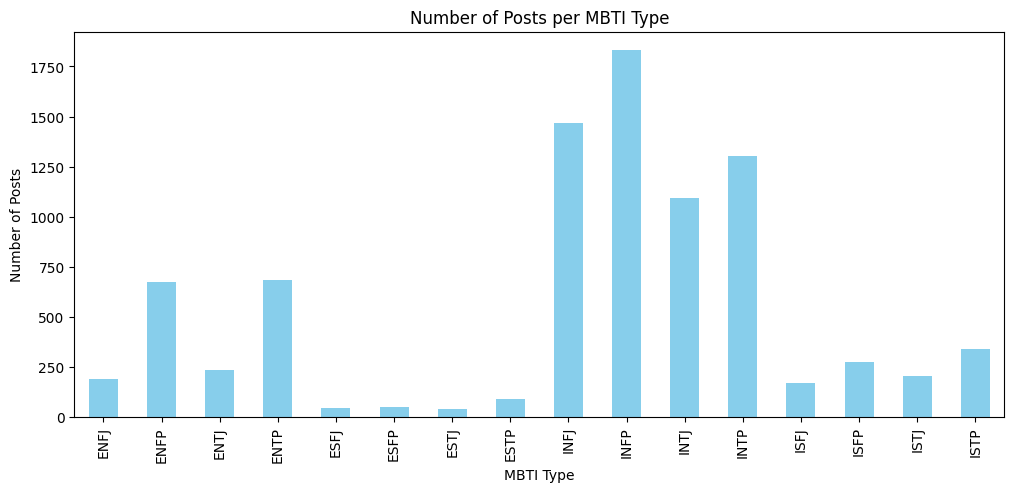

In [111]:
post_counts = df.groupby('type')['posts'].count()
post_counts.plot(kind='bar', figsize=(12,5), color='skyblue')
plt.title("Number of Posts per MBTI Type")
plt.ylabel("Number of Posts")
plt.xlabel("MBTI Type")
plt.show()

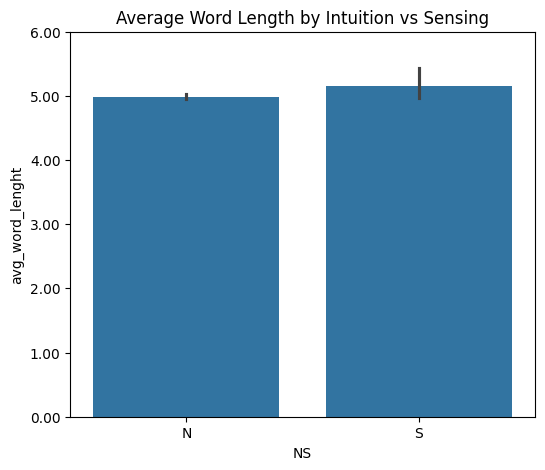

In [141]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='NS', y='avg_word_lenght')
plt.title("Average Word Length by Intuition vs Sensing")
plt.ylim(0,6)
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.show()

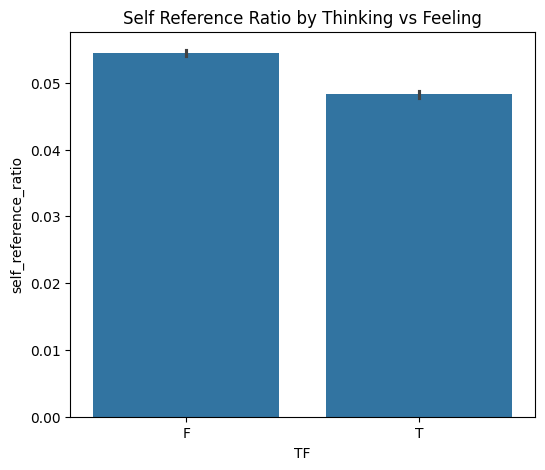

In [115]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='TF', y='self_reference_ratio')
plt.title("Self Reference Ratio by Thinking vs Feeling")
plt.show()


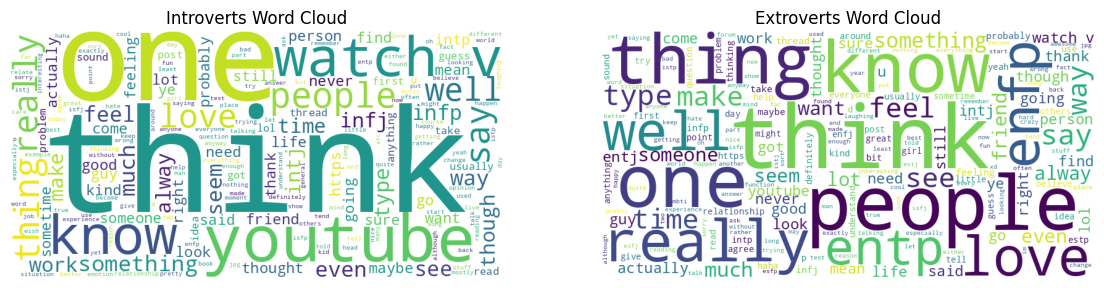

In [116]:

intro_text = " ".join(df[df['IE'] == 'I']['posts']).lower().split()
intro_words = [w for w in intro_text if w not in stop_words]
extro_text = " ".join(df[df['IE'] == 'E']['posts']).lower().split()
extro_words = [w for w in extro_text if w not in stop_words]

intro_clean = " ".join(intro_words)
extro_clean = " ".join(extro_words)

wc_intro = WordCloud(width=800, height=400, background_color='white').generate(intro_clean)
wc_extro = WordCloud(width=800, height=400, background_color='white').generate(extro_clean)

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(wc_intro)
plt.axis("off")
plt.title("Introverts Word Cloud")
plt.subplot(1,2,2)
plt.imshow(wc_extro)
plt.axis("off")
plt.title("Extroverts Word Cloud")
plt.show()

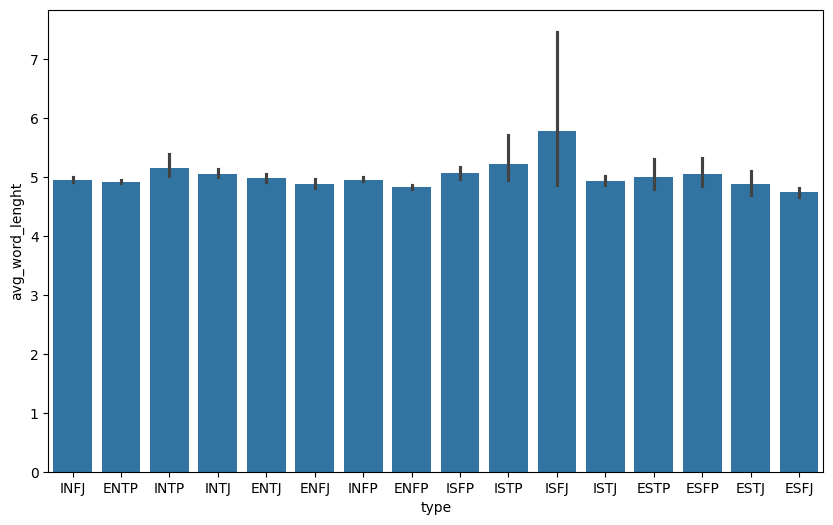

In [117]:
plt.figure(figsize=(10, 6))
sns.barplot(x='type', y='avg_word_lenght', data=df)
plt.show()

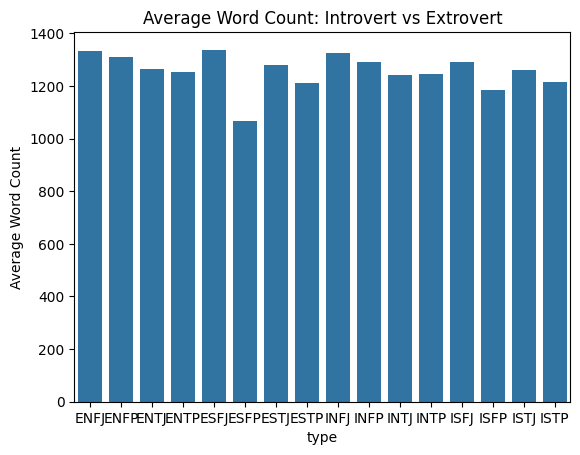

In [161]:

avg_word_count = df.groupby('type')['Word_count'].mean().reset_index()

sns.barplot(x='type', y='Word_count', data=avg_word_count)
plt.title("Average Word Count by type")
plt.ylabel("Average Word Count")
plt.show()

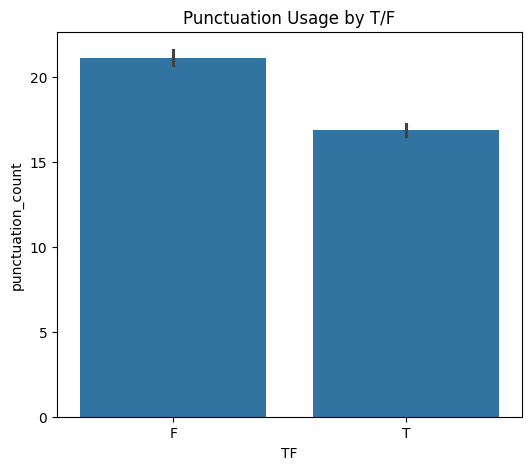

In [162]:
df['punctuation_count'] = df['posts'].apply(lambda x: x.count('!') + x.count('?'))
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='TF', y='punctuation_count')
plt.title("Punctuation Usage by T/F")
plt.show()

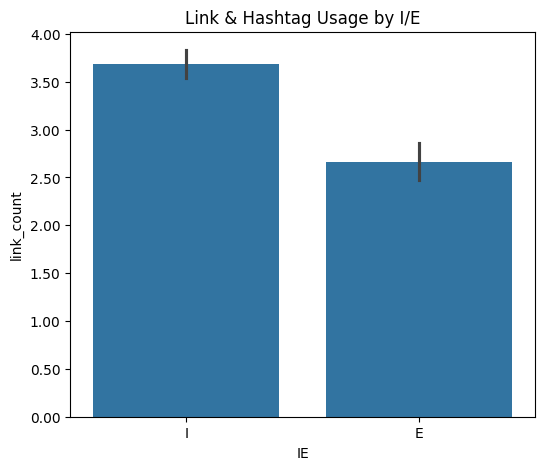

In [144]:
df['link_count'] = df['posts'].apply(lambda x: x.count('http') + x.count('#'))
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='IE', y='link_count')
plt.title("Link & Hashtag Usage by I/E")
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.show()
plt.show()

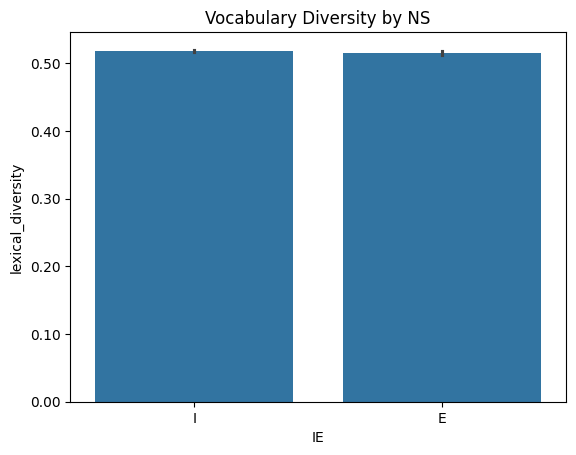

In [145]:
sns.barplot(data=df, x='IE', y='lexical_diversity')
plt.title("Vocabulary Diversity by NS")
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.show()







/tmp/ipykernel_1058/1920067134.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='JP', y='emotion_score', palette=['lightblue','salmon'])


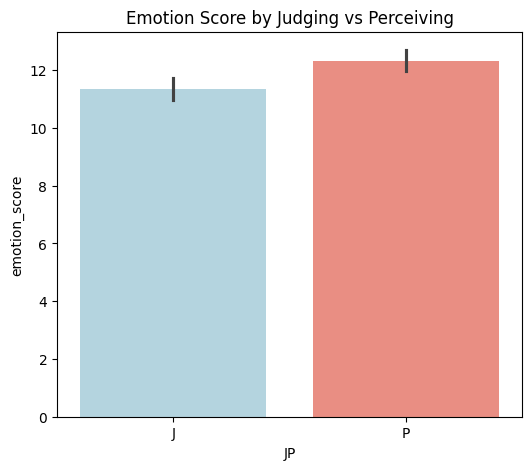

In [163]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='JP', y='emotion_score', palette=['lightblue','salmon'])
plt.title("Emotion Score by Judging vs Perceiving")
plt.show()

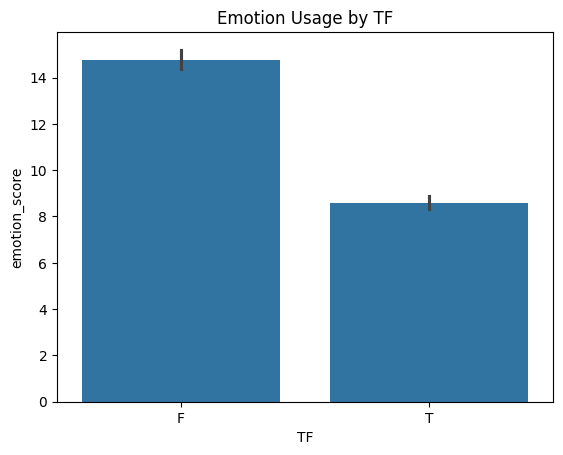

In [123]:
sns.barplot(data=df, x='TF', y='emotion_score')
plt.title("Emotion Usage by TF")
plt.show()

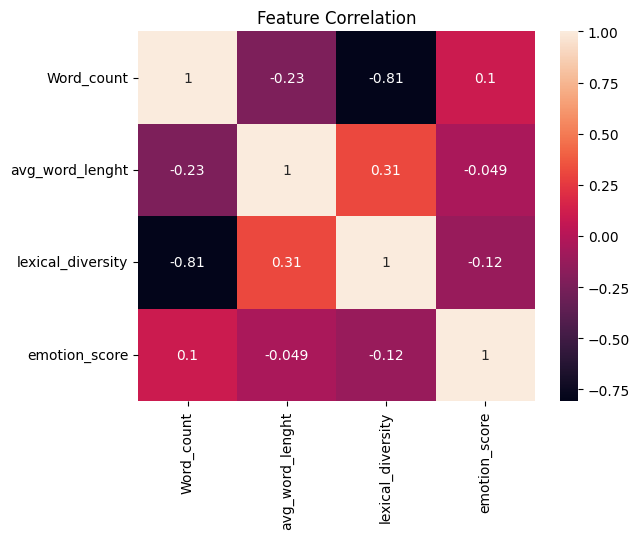

In [124]:
sns.heatmap(df[['Word_count','avg_word_lenght','lexical_diversity','emotion_score']].corr(),annot=True)
plt.title("Feature Correlation")
plt.show()

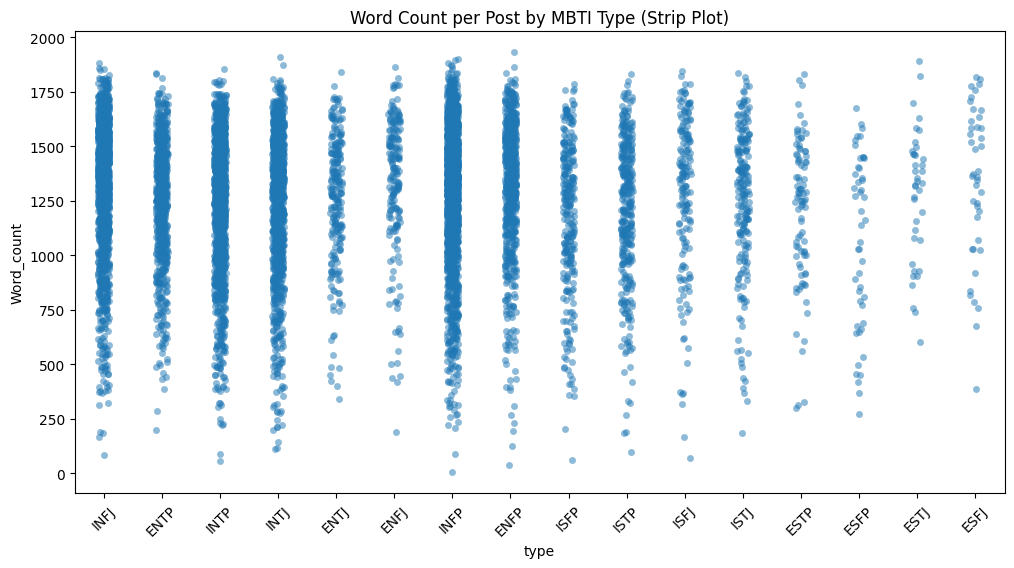

In [125]:
plt.figure(figsize=(12,6))
sns.stripplot(data=df, x='type', y='Word_count', jitter=True, alpha=0.5)
plt.xticks(rotation=45)
plt.title("Word Count per Post by MBTI Type (Strip Plot)")
plt.show()

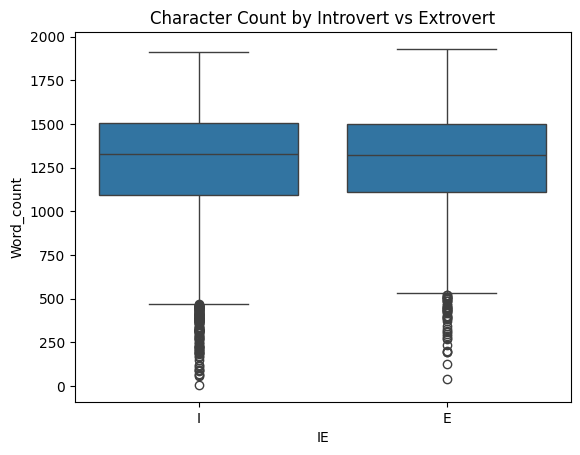

In [126]:
sns.boxplot(data=df, x='IE', y='Word_count')
plt.title("Character Count by Introvert vs Extrovert")
plt.show()

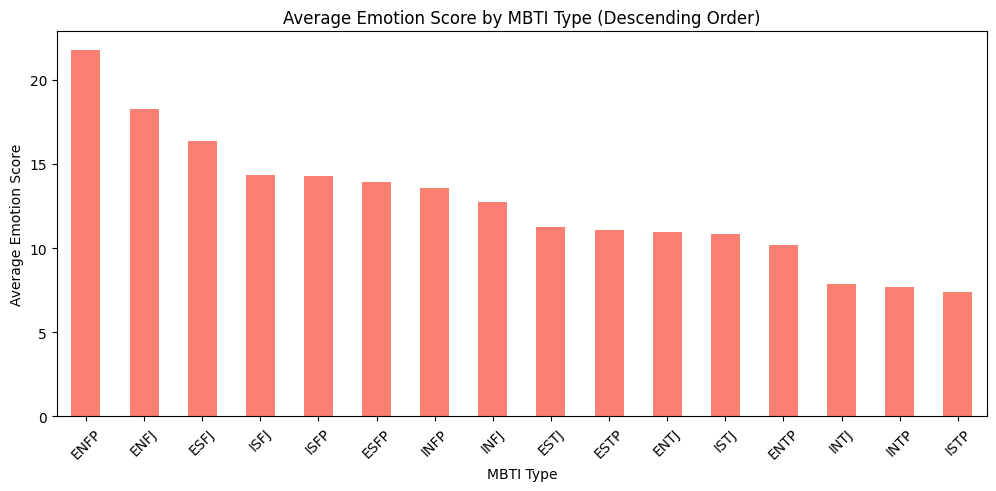

In [150]:

emotion_avg = df.groupby('type')['emotion_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
emotion_avg.plot(kind='bar', color='salmon')
plt.title("Average Emotion Score by MBTI Type (Descending Order)")
plt.ylabel("Average Emotion Score")
plt.xlabel("MBTI Type")
plt.xticks(rotation=45)
plt.show()

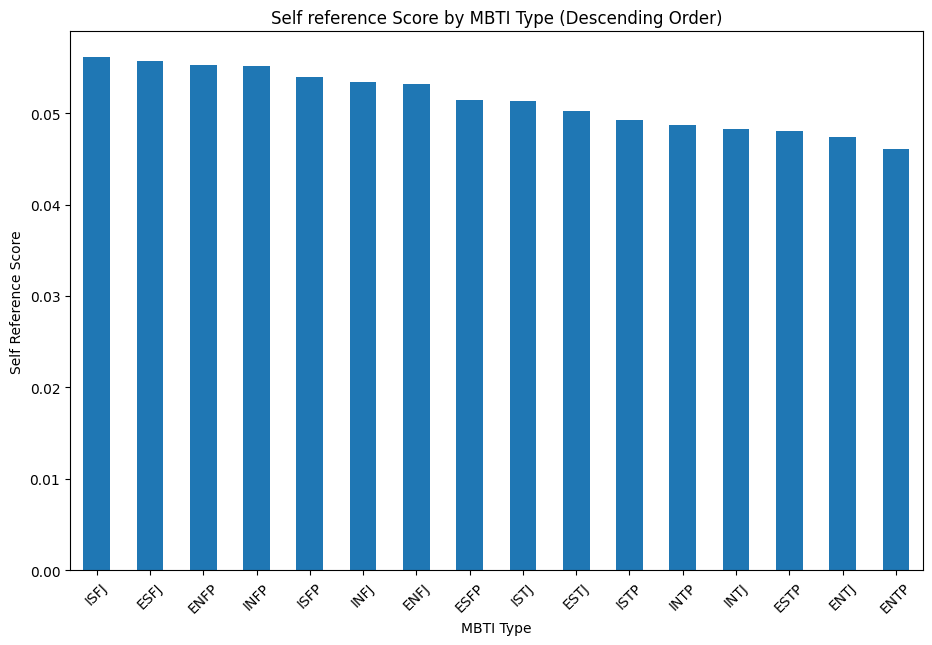

In [157]:
emotion_avg = df.groupby('type')['self_reference_ratio'].mean().sort_values(ascending=False)

plt.figure(figsize=(11,7))
emotion_avg.plot(kind='bar')
plt.title("Self reference Score by MBTI Type (Descending Order)")
plt.ylabel("Self Reference Score")
plt.xlabel("MBTI Type")
plt.xticks(rotation=45)
plt.show()